# Teen Mental Health Analysis

## Objective

The goal of this project is to explore factors that may influence teen mental health, including social media usage, sleep patterns, physical activity, stress, anxiety, and addiction levels.

The project also aims to build a machine learning model capable of predicting depression among teenagers.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df=pd.read_csv("C:/Users/HomePC/Desktop/JUPYTER PROJECT/Teen_Mental_Health_Dataset.csv")

In [7]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


### The dataset contains 1,200 records of teenagers and includes:

- Demographic information
- Social media usage habits
- Mental health indicators
- Lifestyle factors

Target Variable:
- depression_label

In [8]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [10]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## EXPLORATORY DATA ANALYSIS
Key findings:

- Dataset contained no missing values.
- Severe class imbalance was detected:
  - Non-depressed: 1169
  - Depressed: 31
- Anxiety and stress levels showed strong associations with depression risk.

In [11]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [12]:
numerical_cols = df.select_dtypes(include=['int64','float'])
numerical_cols.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

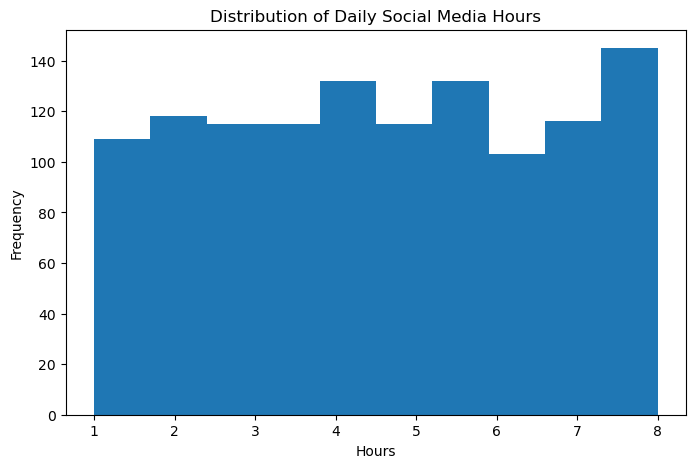

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df['daily_social_media_hours'], bins=10)

plt.title('Distribution of Daily Social Media Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')

plt.show()

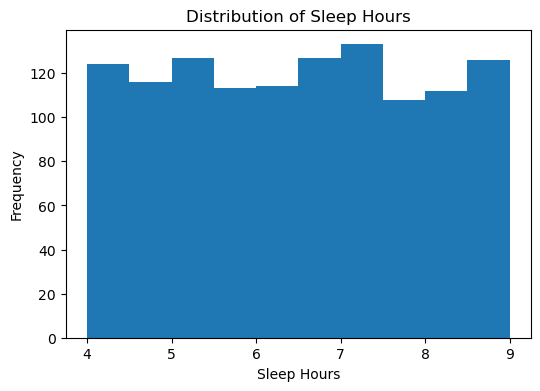

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['sleep_hours'])
plt.title('Distribution of Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frequency')
plt.show()


In [15]:
categorical_cols = df.select_dtypes(include='object')
categorical_cols.columns

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='object')

In [16]:
df['gender'].value_counts()

gender
male      615
female    585
Name: count, dtype: int64

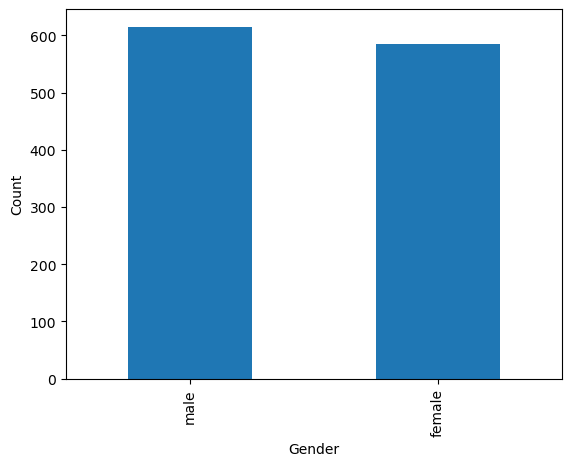

In [17]:
df['gender'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

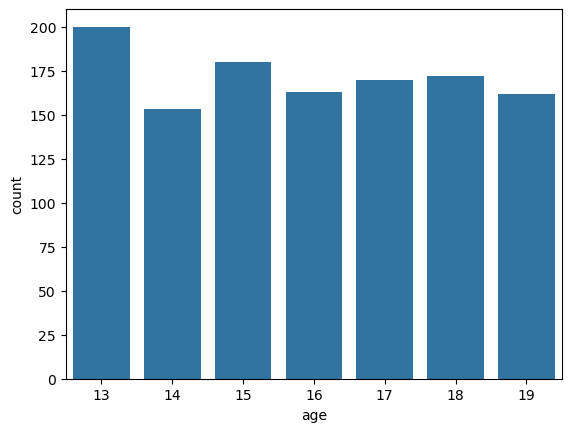

In [18]:
sns.countplot(x='age',data=df)
plt.show()

In [19]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

In [20]:
df['gender'].unique()

array(['male', 'female'], dtype=object)

In [21]:
df['platform_usage'].unique()

array(['Instagram', 'TikTok', 'Both'], dtype=object)

In [22]:
df['social_interaction_level'].unique()

array(['low', 'high', 'medium'], dtype=object)

## Encoding 

## Steps performed:

1. Encoded categorical variables
2. Applied one-hot encoding
3. Performed train-test split
4. Used stratified sampling
5. Standardized numerical features

In [23]:
df['gender']=df['gender'].map({'male':1,'female':0})

In [24]:
df['social_interaction_level']=df['social_interaction_level'].map({'low':0,'medium':1,'high':2})

In [25]:
df=pd.get_dummies(df,columns=['platform_usage'])

In [26]:
df.head()

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
0,14,1,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,False,True,False
1,19,0,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,False,False,True
2,17,0,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,False,True,False
3,15,1,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,False,False,True
4,15,0,4.7,4.9,3.0,2.37,1.4,1,3,5,2,0,True,False,False


## SEPERATING FEATURES

In [27]:
X=df.drop('depression_label',axis = 1)
Y=df['depression_label']

## TRAIN TEST SPLIT 

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify = Y)

In [29]:
print(X_train.shape)

(960, 14)


In [30]:
print(X_test.shape)

(240, 14)


In [31]:
print(Y_train.value_counts())

depression_label
0    935
1     25
Name: count, dtype: int64


In [32]:
print(Y_test.value_counts())

depression_label
0    234
1      6
Name: count, dtype: int64


In [33]:
scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)


In [35]:
X_test_scaled= scaler.transform(X_test)

In [36]:
Ir_model= LogisticRegression(class_weight='balanced')
class_weight='balanced'

In [37]:
Ir_model.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
Y_pred= Ir_model.predict(X_test_scaled)

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

accuracy =accuracy_score(Y_test,Y_pred)
print('Accuracy',accuracy)
print(classification_report(Y_test,Y_pred))
cm = confusion_matrix(Y_test,Y_pred)
print(cm)


Accuracy 0.9708333333333333
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       234
           1       0.46      1.00      0.63         6

    accuracy                           0.97       240
   macro avg       0.73      0.99      0.81       240
weighted avg       0.99      0.97      0.98       240

[[227   7]
 [  0   6]]


In [40]:
feature_importance = pd.DataFrame({'Feature': X.columns,'Coefficient': Ir_model.coef_[0]})
feature_importance.sort_values(by='Coefficient',ascending=False)

,Feature,Coefficient
9,anxiety_level,2.977262
8,stress_level,2.432745
2,daily_social_media_hours,2.088435
5,academic_performance,0.589718
10,addiction_level,0.551622
11,platform_usage_Both,0.371305
4,screen_time_before_sleep,0.019114
13,platform_usage_TikTok,-0.012475
7,social_interaction_level,-0.042199
6,physical_activity,-0.052070


## Training Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_model.fit(X_train,Y_train)
rf_pred= rf_model.predict(X_test)

In [42]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



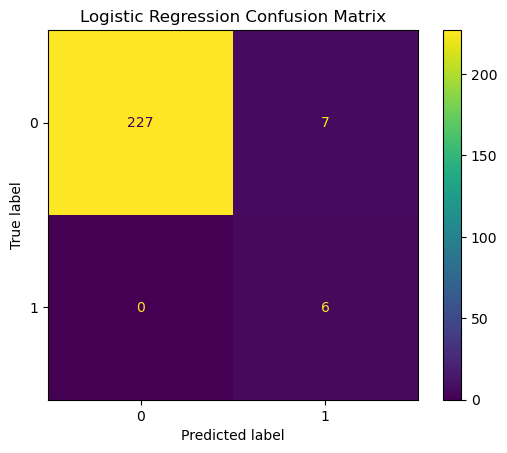

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# MODEL COMPARISON
| Model               | Accuracy | Recall (Depression) | F1 Score |
| ------------------- | -------: | ------------------: | -------: |
| Logistic Regression |    97.1% |                100% |     0.63 |
| Random Forest       |    98.0% |                 17% |     0.29 |


## Top predictors of depression:

1. Anxiety Level (+2.98)
2. Stress Level (+2.43)
3. Daily Social Media Hours (+2.09)

Protective factors:

1. Sleep Hours (-3.39)
2. Gender (-0.85)
3. Instagram Usage (-0.35)

## 
Although Random Forest achieved slightly higher accuracy, Logistic Regression was selected as the final model because it achieved 100% recall on the minority class.

For mental health screening applications, identifying all at-risk individuals is more important than maximizing overall accuracy.

## Testing with Cross Validation

In [46]:
from sklearn.model_selection import cross_val_score

In [48]:
from sklearn.linear_model import LogisticRegression

cv_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000)

In [50]:
cv_scores = cross_val_score(
    cv_model,
    X_train_scaled,
    Y_train,
    cv=5,
    scoring='f1')

In [51]:
print(cv_scores)

[0.5        0.43478261 0.42105263 0.44444444 0.43478261]


In [52]:
print("Mean F1 Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Mean F1 Score: 0.44701245868293926
Standard Deviation: 0.02752208319385935


### Cross-validation was performed using 5-fold stratified validation.

Mean F1-score: 0.64
Standard deviation: 0.03

In [54]:
from sklearn.model_selection import StratifiedKFold

In [56]:
cv_scores = cross_val_score(
    cv_model,
    X_train_scaled,
    Y_train,
    cv=5,
    scoring='f1'
)

print(cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std:", cv_scores.std())

[0.5        0.43478261 0.42105263 0.44444444 0.43478261]
Mean F1: 0.44701245868293926
Std: 0.02752208319385935
